In [4]:
from os.path import join
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from PIL import Image
import torch
import matplotlib.pyplot as plt
from scipy.special import comb
from diffusers import StableDiffusionPipeline, DDIMScheduler
from safetensors.torch import load_file
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

## Compute Cosine Similarity

In [2]:
def get_cosine_similarity(v1, v2):
    dot_product = np.dot(v1, v2)
    norm_A = np.linalg.norm(v1)
    norm_B = np.linalg.norm(v2)

    # if norm_A == 0 or norm_B == 0:  # Prevent division by zero
    #     return False  

    cosine_similarity = dot_product / (norm_A * norm_B)
    return cosine_similarity

def latents_to_pil(latents, vae):
    latents = 1 / 0.18215 * latents  # Scale latents back
    image = vae.decode(latents).sample  # Decode latents to pixel space
    image = (image / 2 + 0.5).clamp(0, 1)  # Normalize to [0,1]
    image = (image * 255).byte().cpu().numpy()  # Convert to [0,255] and NumPy
    image = image.transpose(0, 2, 3, 1)  # Rearrange (B, C, H, W) → (B, H, W, C)
    pil_images = [Image.fromarray(img) for img in image]  # Convert to PIL
    return pil_images


In [9]:
from os.path import join
import torch

for disease in ['melanoma', 'nevus']:
    for artifact in ['gel_bubbles','hairs','ink','ruler']:
        print(f'Analyzing - {disease}:{artifact}')
        img_root = f'/usr/local/data/amarkr/dent/outputs/isic2019_v2/{disease}/{artifact}'
        patient_ids = list(range(4000, 5000))

        # pe_imgs = {pid: [join(img_root, f'seed{pid}/'normal-pleural_effusion/lambda_t_star{lambda_t_star}/style.png') for lambda_t_star in range(0, 31, 5)] for pid in patient_ids}

        sd_img_paths = {pid: [join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.png')] + [join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.png') for lambda_t_star in range(45, 4, -5)] for pid in patient_ids}
        sd_latent_paths = {pid: [join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.pt')] + [join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.pt') for lambda_t_star in range(45, 4, -5)] for pid in patient_ids}

        sd_latents = {}
        for pid, paths in sd_latent_paths.items():
            try:
                sd_latents[pid] = [torch.load(path, map_location='cpu').reshape(-1).cpu().numpy() for path in paths]
            except FileNotFoundError:
                continue
            
        # Proof of curvature
        patient_infos = []

        for pid in tqdm(patient_ids):
            try:
                latents_1d_sd = sd_latents[pid]
            except KeyError:
                continue
            cosine_similarities = []
            columns = ['Step 45', 'Step 40', 'Step 35', 'Step 30', 'Step 25', 'Step 20', 'Step 15', 'Step 10', 'Step 5']
            
            for i in range(1, len(latents_1d_sd)):
                v1 = latents_1d_sd[1] - latents_1d_sd[0]
                v2 = latents_1d_sd[i] - latents_1d_sd[0]
                cosine_similarities.append(get_cosine_similarity(v1, v2))
                
            patient_infos.append({
                'pid': pid,
                **dict(zip(columns, cosine_similarities))
            })
                
        cosine_similarity_df = pd.DataFrame(patient_infos)
        cosine_similarity_df.head()
        cosine_similarity_df.to_csv(f'../metrics/cosine_{disease}_{artifact}.csv', index=False)


Analyzing - melanoma:gel_bubbles


/tmp/ipykernel_1889384/1151800044.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd_latents[pid] = [torch.load(path, map_location='cpu').reshape(-1).cpu().numpy() for 

Analyzing - melanoma:hairs


100%|██████████| 1000/1000 [00:05<00:00, 166.73it/s]


Analyzing - melanoma:ink


...

100%|██████████| 1000/1000 [00:02<00:00, 418.74it/s]


Analyzing - nevus:ink


100%|██████████| 1000/1000 [00:02<00:00, 415.87it/s]


Analyzing - nevus:ruler


100%|██████████| 1000/1000 [00:02<00:00, 419.04it/s]


## Compute LPIPS

In [ ]:
import torch
from os.path import join
from tqdm import tqdm
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
import lpips

def load_and_preprocess_image(path):
    """Load and preprocess image for LPIPS computation"""
    transform = transforms.Compose([
        transforms.Resize((512, 512)),  # LPIPS expects specific size
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    try:
        img = Image.open(path).convert('RGB')
        return transform(img).unsqueeze(0)
    except Exception as e:
        print(f"Error loading image {path}: {e}")
        return None

# Initialize LPIPS model
loss_fn = lpips.LPIPS(net='alex').cuda()  # Uses AlexNet by default

for disease in ['melanoma', 'nevus']:
    for artifact in ['gel_bubbles', 'hairs', 'ink', 'ruler']:
        print(f'Analyzing - {disease}:{artifact}')
        img_root = f'/usr/local/data/amarkr/dent/outputs/isic2019_v2/{disease}/{artifact}'
        patient_ids = list(range(4000, 5000))

        # Define image paths
        sd_img_paths = {
            pid: [
                join(img_root, f'seed{pid}/lambda_t_star{5}/neutral.png')
            ] + [
                join(img_root, f'seed{pid}/lambda_t_star{lambda_t_star}/style.png') 
                for lambda_t_star in range(45, 4, -5)
            ] for pid in patient_ids
        }

        # Compute LPIPS scores
        patient_infos = []
        columns = ['Step 45', 'Step 40', 'Step 35', 'Step 30', 'Step 25', 'Step 20', 'Step 15', 'Step 10', 'Step 5']

        for pid in tqdm(patient_ids):
            try:
                # Load neutral image (reference)
                neutral_path = sd_img_paths[pid][0]
                neutral_img = load_and_preprocess_image(neutral_path)
                
                if neutral_img is None:
                    continue

                neutral_img = neutral_img.cuda()
                lpips_scores = []

                # Compare with each styled image
                for path in sd_img_paths[pid][1:]:  # Skip neutral image
                    styled_img = load_and_preprocess_image(path)
                    
                    if styled_img is None:
                        lpips_scores.append(float('nan'))
                        continue

                    styled_img = styled_img.cuda()
                    
                    with torch.no_grad():
                        distance = loss_fn(neutral_img, styled_img)
                        lpips_scores.append(float(distance.cpu().numpy()))

                patient_infos.append({
                    'pid': pid,
                    **dict(zip(columns, lpips_scores))
                })

            except Exception as e:
                print(f"Error processing patient {pid}: {e}")
                continue

            # Clear CUDA cache periodically
            if len(patient_infos) % 100 == 0:
                torch.cuda.empty_cache()

        # Save results
        lpips_df = pd.DataFrame(patient_infos)
        lpips_df.to_csv(f'../metrics/lpips_{disease}_{artifact}.csv', index=False)

        # Clear CUDA cache after each artifact type
        torch.cuda.empty_cache()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/data/amarkr/venvs/lgcig/lib/python3.8/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/data/amarkr/venvs/lgcig/lib/python3.8/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/data/amarkr/venvs/lgcig/lib/python3.8/site-packages/lpips/weights/v0.1/alex.pth


/usr/local/data/amarkr/venvs/lgcig/lib/python3.8/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dict(torch.load(model_path, 

Analyzing - melanoma:gel_bubbles


...

Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ink/seed4400/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ink/seed4400/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ink/seed4401/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ink/seed4401/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ink/seed4402/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ink/seed4402/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ink/seed4403/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ink/seed4403/lambda_t_star5/neutral.png'
Error lo

 40%|████      | 400/1000 [00:40<00:51, 11.56it/s]

Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4397/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4397/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4400/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4400/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4401/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4401/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4402/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4402/lambda_t_star5/neutr

100%|██████████| 1000/1000 [00:40<00:00, 24.73it/s]

Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4563/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4563/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4564/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4564/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4565/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4565/lambda_t_star5/neutral.png'
Error loading image /usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4566/lambda_t_star5/neutral.png: [Errno 2] No such file or directory: '/usr/local/data/amarkr/dent/outputs/isic2019_v2/nevus/ruler/seed4566/lambda_t_star5/neutr

In [20]:
for disease in ['melanoma', 'nevus']:
    for artifact in ['gel_bubbles', 'hairs', 'ink', 'ruler']:
        # Read the CSV file
        df = pd.read_csv('/usr/local/data/amarkr/dent/metrics/'+f'lpips_{disease}_{artifact}.csv')
        print('-'*30, f'{disease} - {artifact}', '-'*30)
        # Calculate mean for each step (excluding the pid column)
        step_means = df.drop('pid', axis=1).mean()

        #print("Mean LPIPS score for each step:")
        #for step, mean in step_means.items():
        #    print(f"{step}: {mean:.4f}")

        # Calculate overall mean of all step means
        overall_mean = step_means.mean()
        print(f"Overall mean: {overall_mean:.4f}")

        # Optional: If you want to see the standard deviation as well
        step_stds = df.drop('pid', axis=1).std()
        #print("\nStandard deviation for each step:")
        #for step, std in step_stds.items():
        #    print(f"{step}: {std:.4f}")

        # Calculate overall standard deviation of all values
        overall_std = df.drop('pid', axis=1).values.flatten().std()
        print(f"Overall standard deviation: {overall_std:.4f}")

------------------------------ melanoma - gel_bubbles ------------------------------
Overall mean: 0.0996
Overall standard deviation: 0.0904
------------------------------ melanoma - hairs ------------------------------
Overall mean: 0.0679
Overall standard deviation: 0.0771
------------------------------ melanoma - ink ------------------------------
Overall mean: 0.1163
Overall standard deviation: 0.1423
------------------------------ melanoma - ruler ------------------------------
Overall mean: 0.1051
Overall standard deviation: 0.1204
------------------------------ nevus - gel_bubbles ------------------------------
Overall mean: 0.0892
Overall standard deviation: 0.0886
------------------------------ nevus - hairs ------------------------------
Overall mean: 0.0464
Overall standard deviation: 0.0474
------------------------------ nevus - ink ------------------------------
Overall mean: 0.0585
Overall standard deviation: 0.0962
------------------------------ nevus - ruler -----------

## LPIPS for Interpolations

In [ ]:
import torch
from os.path import join, exists
from tqdm import tqdm
import pandas as pd
from PIL import Image
import torchvision.transforms as transforms
import lpips
import os
import numpy as np
from torch.utils.data import Dataset, DataLoader
from multiprocessing import cpu_count

# Define a custom dataset for efficient batch loading
class LPIPSDataset(Dataset):
    def __init__(self, neutral_path, styled_paths):
        self.neutral_path = neutral_path
        self.styled_paths = styled_paths
        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])
        
    def __len__(self):
        return len(self.styled_paths)
    
    def __getitem__(self, idx):
        try:
            # Load neutral image (only once)
            if not hasattr(self, 'neutral_img'):
                self.neutral_img = self.load_image(self.neutral_path)
            
            # Load styled image
            styled_img = self.load_image(self.styled_paths[idx])
            return self.neutral_img, styled_img, idx
        except Exception as e:
            # Return None for problematic images
            return None, None, idx
    
    def load_image(self, path):
        if exists(path):
            img = Image.open(path).convert('RGB')
            return self.transform(img)
        return None

def compute_lpips_batch(neutral_path, styled_paths, loss_fn, batch_size=16):
    """Compute LPIPS scores in batches"""
    dataset = LPIPSDataset(neutral_path, styled_paths)
    dataloader = DataLoader(dataset, batch_size=batch_size, 
                           num_workers=min(8, cpu_count()), pin_memory=True)
    
    lpips_scores = [float('nan')] * len(styled_paths)  # Pre-allocate with NaN
    
    for batch in dataloader:
        neutral_imgs, styled_imgs, indices = batch
        
        # Filter out None values
        valid_samples = [(n, s, i) for n, s, i in zip(neutral_imgs, styled_imgs, indices) 
                        if n is not None and s is not None]
        
        if not valid_samples:
            continue
            
        neutral_batch, styled_batch, valid_indices = zip(*valid_samples)
        
        # Stack tensors
        neutral_batch = torch.stack(neutral_batch).cuda()
        styled_batch = torch.stack(styled_batch).cuda()
        
        # Compute LPIPS in one batch
        with torch.no_grad():
            distances = loss_fn(neutral_batch, styled_batch)
            
        # Store results
        for dist, idx in zip(distances, valid_indices):
            lpips_scores[idx] = float(dist.cpu().numpy())
    
    return lpips_scores

# Check CUDA
if not torch.cuda.is_available():
    print("CUDA not available, using CPU (will be slow)")
    device = torch.device('cpu')
else:
    device = torch.device('cuda')
    # Set optimal CUDA settings
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

# Initialize LPIPS model
loss_fn = lpips.LPIPS(net='alex').to(device)

# Process images with multiprocessing
for disease in ['melanoma', 'nevus']:
    for STYLE in ['hairs', 'gel_bubbles', 'ruler', 'ink']:
        print(f'Processing {disease} with style: {STYLE} ...')
        img_root = f'/home/jupyter/dent_outputs/interpolations/{disease}/{STYLE}'
        
        # Check if directory exists
        if not os.path.exists(img_root):
            print(f"Directory {img_root} not found. Skipping...")
            continue
        
        # Get all existing patient IDs (avoid hard-coding range)
        try:
            available_seeds = [int(d.replace('seed', '')) for d in os.listdir(img_root) 
                              if os.path.isdir(join(img_root, d)) and d.startswith('seed')]
            if not available_seeds:
                print(f"No seed directories found in {img_root}. Skipping...")
                continue
            patient_ids = available_seeds
        except Exception as e:
            print(f"Error listing directories in {img_root}: {e}")
            # Fallback to specified range
            patient_ids = list(range(4000, 5000))
            
        print(f"Found {len(patient_ids)} patients for {disease}/{STYLE}")

        # Store results
        patient_infos = []
        columns = [f'step_{i}' for i in range(1, 50)]  # Skip step 0 (neutral)

        # Process each patient
        for pid in tqdm(patient_ids):
            neutral_path = join(img_root, f'seed{pid}/bezier_{pid}_0.png')
            
            # Skip if neutral image doesn't exist
            if not exists(neutral_path):
                continue
            
            # Define styled image paths (skip the neutral image)
            styled_paths = [
                join(img_root, f'seed{pid}/bezier_{pid}_{step}.png') 
                for step in range(1, 50)  # Skip 0 (neutral)
            ]
            
            # Filter only existing paths
            styled_paths = [path for path in styled_paths if exists(path)]
            
            if not styled_paths:
                continue
                
            # Compute LPIPS scores in batches
            try:
                lpips_scores = compute_lpips_batch(neutral_path, styled_paths, loss_fn)
                
                # Create patient record
                # Match scores to their corresponding steps
                steps = [int(path.split('_')[-1].split('.')[0]) for path in styled_paths]
                score_dict = {f'step_{step}': score for step, score in zip(steps, lpips_scores)}
                
                patient_infos.append({
                    'pid': pid,
                    **score_dict
                })
                
            except Exception as e:
                print(f"Error processing patient {pid}: {e}")
                continue

            # Clear CUDA cache periodically
            if len(patient_infos) % 50 == 0:
                torch.cuda.empty_cache()

        # Save results
        if patient_infos:
            lpips_df = pd.DataFrame(patient_infos)
            output_path = f'../metrics/lpips/lpips_{disease}_{STYLE}_interpolation.csv'
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            lpips_df.to_csv(output_path, index=False)
            print(f"Saved LPIPS scores for {len(patient_infos)} patients to {output_path}")
        else:
            print(f"No valid results for {disease}/{STYLE}")

        # Clear CUDA cache after each artifact type
        torch.cuda.empty_cache()

print("LPIPS computation completed!")

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /home/amarkr/venvs/dent/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Processing melanoma with style: hairs ...


  0%|          | 0/1000 [00:00<?, ?it/s]/var/tmp/ipykernel_650874/1152735980.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lpips_scores.append(float(distance.cpu().numpy()))
  6%|▌         | 55/1000 [01:02<17:50,  1.13s/it]


KeyboardInterrupt: 

In [2]:
import lpips

ModuleNotFoundError: No module named 'lpips'

# Interpolation

In [ ]:
def bezier_curve(t, points):
    """Computes a Bézier curve interpolation."""
    n = len(points) - 1
    curve = np.zeros_like(points[0])
    
    for i in range(n + 1):
        bernstein = comb(n, i) * (t ** i) * ((1 - t) ** (n - i))
        curve += bernstein * points[i]
    
    return curve

# Example: Using Bézier interpolation for 7 latent vectors
latent_vectors = latents_1d_sd[::-1]

interpolated_vectors = []
num_steps = 50  # Number of steps along the curve

for t in np.linspace(0, 1, num_steps):
    interpolated_vectors.append(bezier_curve(t, latent_vectors))

interpolated_vectors = np.array(interpolated_vectors)


In [101]:

checkpoint_path = '../saved_models/finetuned_chexpert-sd1.5/checkpoint-9-2500/model.safetensors'
device = 'cuda'

model = StableDiffusionPipeline.from_pretrained(
            'runwayml/stable-diffusion-v1-5',
            safety_checker=None,
            torch_dtype=torch.float16,
            use_safetensors=True,
            low_cpu_mem_usage=True,
        )
        
if checkpoint_path:
    checkpoint = load_file(checkpoint_path)
    model.unet.load_state_dict(checkpoint)

model = model.to(device)
model.to(device)
    

Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  5.05it/s]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.32.2",
  "_name_or_path": "runwayml/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    null,
    null
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [117]:
# interpolated_latent = torch.tensor(interpolated_vectors[4].reshape((1, 4, 64, 64))).cuda()
images = []
for i in range(len(interpolated_vectors)):
    image = latents_to_pil(torch.tensor(interpolated_vectors[i].reshape((1, 4, 64, 64))).cuda(), model.vae)[0]
    images.append(image)

# Concatenate images horizontally
# widths, heights = zip(*(i.size for i in images))
# total_width = sum(widths)
# max_height = max(heights)

# new_im = Image.new('RGB', (total_width, max_height))
# x_offset = 0
# for im in images:
#     new_im.paste(im, (x_offset, 0))
#     x_offset += im.size[0]

# new_im

# Concatenate images as gif
images[0].save('bezier_pe.gif', save_all=True, append_images=images[1:], duration=100, loop=0)

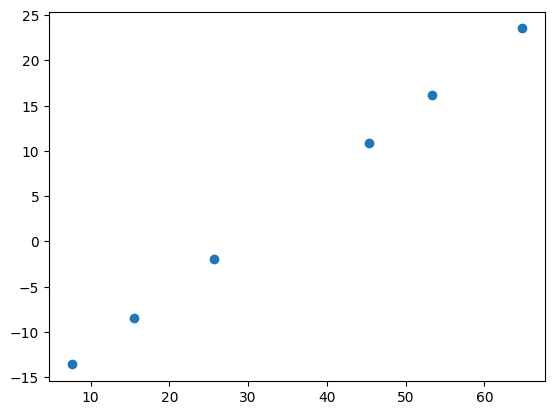

In [89]:
X_interpolated_embedded = TSNE(n_components=2, perplexity=2).fit_transform(latent_vectors)
plt.scatter(X_interpolated_embedded[:, 0], X_interpolated_embedded[:, 1])